In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## **Modeling Setup**

In [2]:
df = pd.read_csv('data_cleaned.csv')
df['Log_Price'] = np.log(df['Price'])

cat_cols = ['Apartment type', 'Region', 'Renovation']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

display(df.head(), df.shape)

,Price,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Log_Price,Apartment type_Secondary,Region_Moscow region,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
0,6300000.0,Опалиха,6.0,1.0,30.6,11.1,8.5,25.0,25,15.656060,1,1,0,0,0
1,9000000.0,Павшино,2.0,1.0,49.2,20.0,10.0,6.0,15,16.012735,1,1,0,1,0
2,11090000.0,Мякинино,14.0,1.0,44.7,16.2,13.1,10.0,25,16.221554,1,1,0,0,0
3,8300000.0,Строгино,8.0,1.0,35.1,16.0,11.0,12.0,33,15.931766,1,1,0,1,0
4,6450000.0,Опалиха,6.0,1.0,37.7,15.2,4.0,5.0,5,15.679591,1,1,0,0,1


(18374, 15)

In [3]:
X = df.drop(columns = ['Price', 'Log_Price', 'Metro station'])
y = df['Log_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")
print(f"\nFeature names:\n{list(X.columns)}")

Training set:  (14699, 12)
Test set:      (3675, 12)
Total features: 12

Feature names:
['Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Apartment type_Secondary', 'Region_Moscow region', 'Renovation_Designer', 'Renovation_European-style renovation', 'Renovation_Without renovation']


## **OLS Linear Regression (Baseline)**

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Shared preprocessor -- used by OLS, Lasso, and Ridge so all coefficients are on the same scale
numeric_cols = ['Minutes to metro', 'Number of rooms', 'Area',
                'Living area', 'Kitchen area', 'Floor', 'Number of floors']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_cols)],
    remainder='passthrough'
)

# OLS fit through the same preprocessor so coefficients are on the same scale as Lasso/Ridge
ols_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('ols', LinearRegression())
])

ols_pipeline.fit(X_train, y_train)

y_pred_ols_train = ols_pipeline.predict(X_train)
y_pred_ols_test  = ols_pipeline.predict(X_test)

train_r2_score = r2_score(y_train, y_pred_ols_train)
test_r2_score  = r2_score(y_test, y_pred_ols_test)
rmse_log       = np.sqrt(mean_squared_error(y_test, y_pred_ols_test))
mae_rub        = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ols_test))
mape_ols       = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_ols_test)) * 100

print("=== OLS Linear Regression ===")
print(f"Train R²:         {train_r2_score:.4f}")
print(f"Test R²:          {test_r2_score:.4f}")
print(f"RMSE (log):       {rmse_log:.4f}")
print(f"MAE (₽):          {mae_rub:,.0f}")
print(f"MAPE:             {mape_ols:.2f}%")

=== OLS Linear Regression ===
Train R²:         0.8599
Test R²:          0.8694
RMSE (log):       0.3888
MAE (₽):          26,525,122
MAPE:             28.45%


In [5]:
# Feature name order after ColumnTransformer: numeric (scaled) first, then dummies (passthrough)
dummy_cols = [col for col in X_train.columns if col not in numeric_cols]
feature_names_scaled = numeric_cols + dummy_cols

ols_coef_series = pd.Series(ols_pipeline.named_steps['ols'].coef_, index=feature_names_scaled)
print(ols_coef_series.round(4))

Minutes to metro                       -0.0889
Number of rooms                         0.2209
Area                                    0.3946
Living area                             0.0209
Kitchen area                            0.1104
Floor                                  -0.0015
Number of floors                        0.0125
Apartment type_Secondary                0.3314
Region_Moscow region                   -0.4331
Renovation_Designer                     0.6651
Renovation_European-style renovation    0.2618
Renovation_Without renovation           0.4052
dtype: float64


In [6]:
coef_df_ols = ols_coef_series.abs().sort_values(ascending=False)
print("Top 5 features by |coefficient| (standardized scale):")
print(coef_df_ols.head(5))

Top 5 features by |coefficient| (standardized scale):
Renovation_Designer              0.665149
Region_Moscow region             0.433070
Renovation_Without renovation    0.405167
Area                             0.394605
Apartment type_Secondary         0.331429
dtype: float64


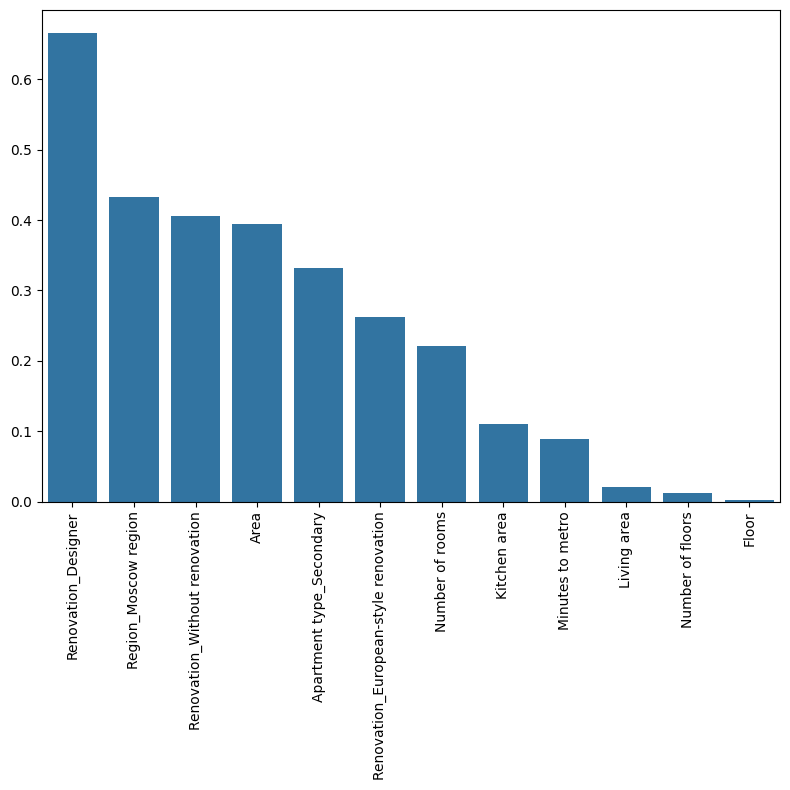

In [7]:
plt.figure(figsize=(8, 8))
sns.barplot(coef_df_ols)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### OLS Regression -- Findings

A standard OLS linear regression on all 12 features gives a solid baseline. The model explains about 87% of the variation in log-transformed apartment prices on the held-out test set (Test R² = 0.87), with almost no gap from training (Train R² = 0.86). That small spread suggests the model generalizes well and is not overfitting. In price terms, predictions are off by about 26.5M rubles on average (MAE) and 28.5% on a percentage basis (MAPE).

With all features on a standardized scale, the coefficient picture is clear. Renovation quality and location are the two dominant price drivers. Designer renovation commands the largest premium (+0.67 log units) relative to the baseline of cosmetic renovation. Being in Moscow city rather than the surrounding Moscow region also adds a lot of value -- the Region_Moscow region coefficient is -0.43, meaning suburban listings are penalized that much relative to city apartments. Area is right behind at +0.39, confirming that size matters a lot once everything is on a fair footing.

A few things worth noting about reference categories. With drop_first=True, the baselines are Cosmetic renovation, Moscow city, and New building apartment type. So coefficients for renovation are all relative to cosmetic -- and every other renovation type is priced higher than cosmetic. The "Without renovation" coefficient (+0.41) looks counterintuitive at first, but cosmetic renovation appears to be the lowest-quality finish category in this dataset, so unrenovated apartments still price above it. Similarly, secondary market apartments are priced above new buildings on average (+0.33), likely because secondary stock tends to sit in more established, central Moscow neighborhoods.

Floor is essentially zero (-0.002) and will almost certainly get dropped by regularized models. The log-scale RMSE of 0.39 is the primary accuracy metric throughout -- ruble-denominated numbers (MAE, MAPE) are useful context but get pulled around by high-value listings.

## **Lasso Model**

In [8]:
from sklearn.linear_model import LassoCV

In [9]:
lasso_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('lasso', LassoCV(
        cv=10,
        random_state=42,
        max_iter=10000
    ))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso_train = lasso_pipeline.predict(X_train)
y_pred_lasso_test  = lasso_pipeline.predict(X_test)

# Metrics
lasso_train_r2 = r2_score(y_train, y_pred_lasso_train)
lasso_test_r2  = r2_score(y_test, y_pred_lasso_test)
lasso_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_lasso_test))
lasso_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_lasso_test)) * 100

best_alpha  = lasso_pipeline.named_steps['lasso'].alpha_
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_
n_zeroed    = np.sum(lasso_coefs == 0)
n_kept      = np.sum(lasso_coefs != 0)

print("=== Lasso Regression ===")
print(f"Best alpha:       {best_alpha:.6f}")
print(f"Features kept:    {n_kept} / {X_train.shape[1]}")
print(f"Features zeroed:  {n_zeroed}")
print(f"Train R²:         {lasso_train_r2:.4f}")
print(f"Test R²:          {lasso_test_r2:.4f}")
print(f"RMSE (log):       {lasso_rmse_log:.4f}")
print(f"MAE (₽):          {lasso_mae_rub:,.0f}")
print(f"MAPE:             {lasso_mape:.2f}%")

coef_series = pd.Series(lasso_coefs, index=feature_names_scaled)
print("\nZeroed out features:")
print(coef_series[coef_series == 0].index.tolist())
print("\nKept features (by |coefficient|):")
print(coef_series[coef_series != 0].abs().sort_values(ascending=False))

=== Lasso Regression ===
Best alpha:       0.000852
Features kept:    11 / 12
Features zeroed:  1
Train R²:         0.8599
Test R²:          0.8694
RMSE (log):       0.3889
MAE (₽):          26,833,143
MAPE:             28.41%

Zeroed out features:
['Floor']

Kept features (by |coefficient|):
Renovation_Designer                     0.647620
Region_Moscow region                    0.432241
Area                                    0.396803
Renovation_Without renovation           0.388005
Apartment type_Secondary                0.338869
Renovation_European-style renovation    0.247459
Number of rooms                         0.220170
Kitchen area                            0.110633
Minutes to metro                        0.088055
Living area                             0.020605
Number of floors                        0.011610
dtype: float64


## Lasso Regression -- Findings

Lasso with 10-fold cross-validation selected alpha = 0.000852 and zeroed out exactly one feature: Floor. This was predictable -- Floor had nearly zero correlation with price in the EDA and a near-zero coefficient in OLS (-0.002). Every other feature was kept, which tells us the original feature set was already lean. There was nothing wasteful to trim.

Performance is essentially identical to OLS (Test R² = 0.87, RMSE log = 0.39, MAPE = 28%), which makes sense when only one near-zero feature gets dropped. The value of Lasso here is confirmation, not accuracy gain.

The bigger story is what the coefficient table now shows. Once all models are on a standardized scale, OLS and Lasso agree on nearly every coefficient. Area is 0.395 in OLS and 0.397 in Lasso. Renovation_Designer is 0.665 vs 0.648. Region_Moscow region is -0.433 vs -0.432. The differences are rounding noise. Lasso slightly shrinks coefficients for features with more redundancy (like Living area staying small at 0.02 while Area gets 0.40), but both models tell the same story. The takeaway here is not that regularization "fixed" anything -- it is that the features are genuinely informative and the coefficient estimates are stable across modeling approaches.

## **Ridge Model**

In [10]:
from sklearn.linear_model import RidgeCV

ridge_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('ridge', RidgeCV(
        alphas=np.logspace(-3, 3, 100),
        cv=10
    ))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge_train = ridge_pipeline.predict(X_train)
y_pred_ridge_test  = ridge_pipeline.predict(X_test)

# Metrics
ridge_train_r2 = r2_score(y_train, y_pred_ridge_train)
ridge_test_r2  = r2_score(y_test, y_pred_ridge_test)
ridge_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ridge_test))
ridge_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_ridge_test)) * 100

best_alpha_ridge = ridge_pipeline.named_steps['ridge'].alpha_
ridge_coefs      = ridge_pipeline.named_steps['ridge'].coef_

print("=== Ridge Regression ===")
print(f"Best alpha:        {best_alpha_ridge:.4f}")
print(f"Train R²:          {ridge_train_r2:.4f}")
print(f"Test R²:           {ridge_test_r2:.4f}")
print(f"RMSE (log):        {ridge_rmse_log:.4f}")
print(f"MAE (₽):           {ridge_mae_rub:,.0f}")
print(f"MAPE:              {ridge_mape:.2f}%")

# Coefficient comparison -- all three models on the same standardized scale
coef_compare = pd.DataFrame({
    'OLS':   ols_pipeline.named_steps['ols'].coef_,
    'Lasso': lasso_pipeline.named_steps['lasso'].coef_,
    'Ridge': ridge_coefs
}, index=feature_names_scaled).round(4)

print("\nCoefficient comparison (standardized scale -- all models):")
print(coef_compare)

=== Ridge Regression ===
Best alpha:        6.5793
Train R²:          0.8599
Test R²:           0.8694
RMSE (log):        0.3888
MAE (₽):           26,468,105
MAPE:              28.41%

Coefficient comparison (standardized scale -- all models):
                                         OLS   Lasso   Ridge
Minutes to metro                     -0.0889 -0.0881 -0.0889
Number of rooms                       0.2209  0.2202  0.2208
Area                                  0.3946  0.3968  0.3938
Living area                           0.0209  0.0206  0.0221
Kitchen area                          0.1104  0.1106  0.1109
Floor                                -0.0015 -0.0000 -0.0015
Number of floors                      0.0125  0.0116  0.0127
Apartment type_Secondary              0.3314  0.3389  0.3337
Region_Moscow region                 -0.4331 -0.4322 -0.4327
Renovation_Designer                   0.6651  0.6476  0.6598
Renovation_European-style renovation  0.2618  0.2475  0.2585
Renovation_Without reno

## Ridge Regression -- Findings

Ridge with 10-fold cross-validation landed on alpha = 6.58. Unlike Lasso, Ridge keeps all 12 features -- it shrinks coefficients toward zero but never eliminates them. Floor survives at -0.0015, about the same as OLS, which again confirms it carries almost no signal.

Predictive accuracy matches OLS and Lasso exactly (Test R² = 0.87, RMSE log = 0.39, MAPE = 28%). All three linear models are in agreement on how well this feature set can predict price.

The coefficient comparison table is the main result here. Across all three models, every coefficient is nearly identical. OLS, Lasso, and Ridge all agree: Area is around 0.39-0.40, Designer renovation is 0.65-0.67, Moscow city vs. region is 0.43, no renovation vs. cosmetic is 0.39-0.41. The largest gap anywhere in the table is about 0.02, which is well within noise.

This has an important implication for interpretation. The previous version of this analysis attributed the difference between raw OLS and regularized model coefficients to multicollinearity -- specifically, that Area appeared to jump from near-zero to 0.40 when regularization was applied. That was a scaling artifact. Raw OLS coefficients are in original units (per m², per floor, etc.), while Lasso and Ridge were fit on standardized features. Once OLS is put on the same standardized scale, it matches the regularized models almost exactly. The linear model story is straightforward: the feature set is well-conditioned, coefficient estimates are stable, and regularization is not doing any heavy lifting here beyond minor shrinkage and Lasso's cleanup of Floor.